# BOREAS Velocity Visualization

This notebook visualizes the linear and angular velocities of a sequence from the BOREAS dataset. It plots each velocity component (vx, vy, vz for linear; wx, wy, wz for angular) separately in a 3x2 figure layout.

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from pyboreas import BoreasDataset

In [2]:
# Load the BOREAS dataset
root = "/data/boreas/"  # Update with your actual path
bd = BoreasDataset(root)

# Get the first sequence
seq = bd.sequences[0]

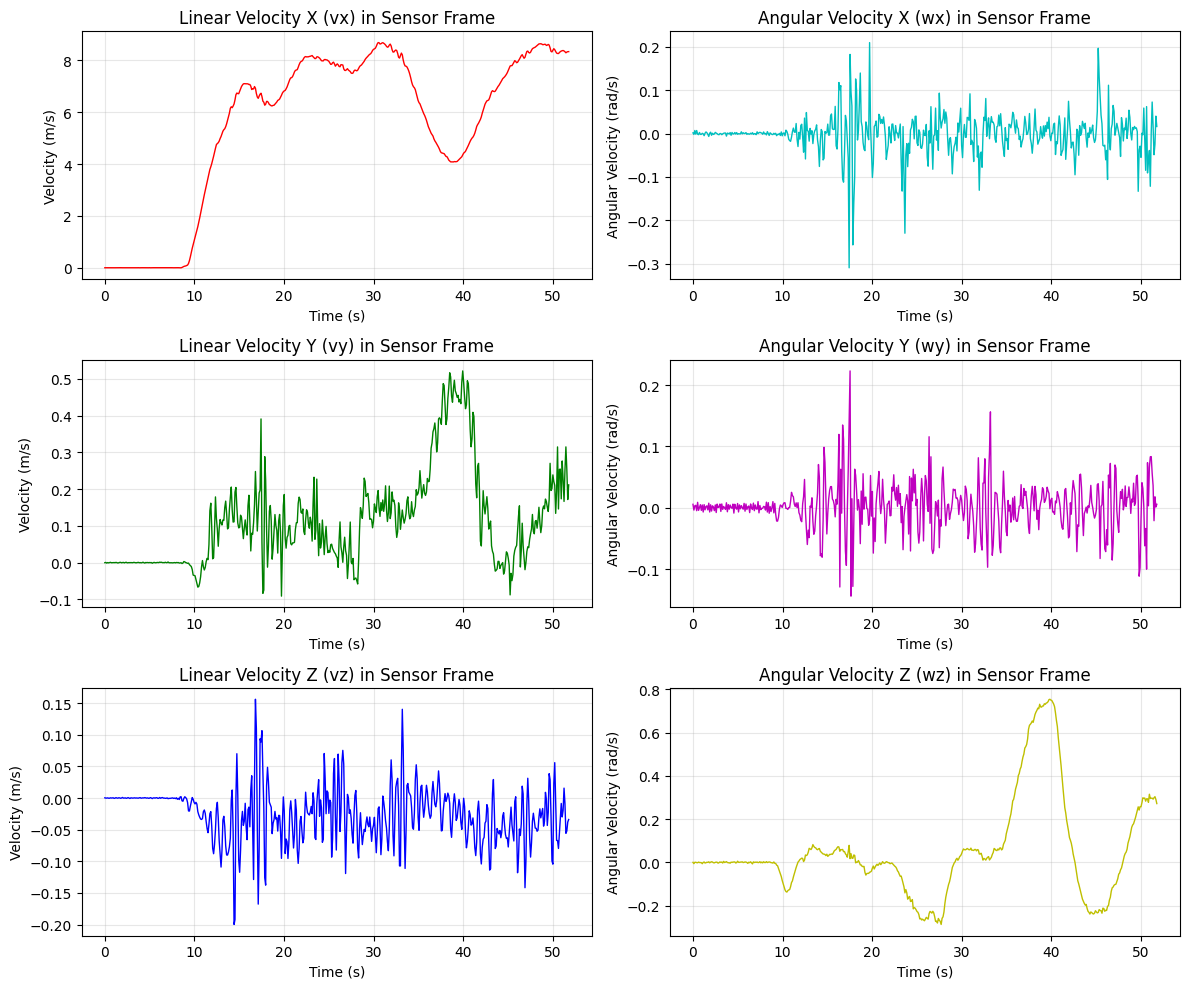

In [3]:
# Plot velocities of the first 500 frames
# First row: vx and wx (linear x, angular x)
# Second row: vy and wy (linear y, angular y)
# Third row: vz and wz (linear z, angular z)

N_FRAMES = 500

# Initialize lists to store velocity data
vx_data = []
vy_data = []
vz_data = []
wx_data = []
wy_data = []
wz_data = []
t_data = []

first_ts = None

from math import pi

angle = pi / 4
# Rotation matrix for rotation around z-axis
cos_theta = np.cos(angle)
sin_theta = np.sin(angle)

# Rotation matrix
R = np.array([
    [cos_theta, -sin_theta, 0], 
    [sin_theta, cos_theta, 0], 
    [0, 0, 1]
    ])

# Iterate through lidar frames
for lidar_frame in seq.lidar:
    if len(vx_data) >= N_FRAMES:
        break

    # Access velocity data from the sensor frame
    # varpi contains [v_se_in_s; w_se_in_s] - velocities in sensor frame
    varpi = lidar_frame.body_rate  # 6x1 vel in sensor frame [vx, vy, vz, wx, wy, wz]

    v = R.T @ varpi[:3] 
    w = R.T @ varpi[3:]
    vx_data.append(v[0])
    vy_data.append(v[1])
    vz_data.append(v[2])
    wx_data.append(w[0])
    wy_data.append(w[1])
    wz_data.append(w[2])
    if (first_ts is None):
        first_ts = lidar_frame.timestamp
    t_data.append(lidar_frame.timestamp - first_ts)

    # Unload data to manage memory
    lidar_frame.unload_data()

# Create 3x2 figure layout
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# First row: vx and wx
axes[0, 0].plot(t_data, vx_data, "r-", linewidth=1)
axes[0, 0].set_title("Linear Velocity X (vx) in Sensor Frame")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Velocity (m/s)")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(t_data, wx_data, "c-", linewidth=1)
axes[0, 1].set_title("Angular Velocity X (wx) in Sensor Frame")
axes[0, 1].set_xlabel("Time (s)")
axes[0, 1].set_ylabel("Angular Velocity (rad/s)")
axes[0, 1].grid(True, alpha=0.3)

# Second row: vy and wy
axes[1, 0].plot(t_data, vy_data, "g-", linewidth=1)
axes[1, 0].set_title("Linear Velocity Y (vy) in Sensor Frame")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Velocity (m/s)")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(t_data, wy_data, "m-", linewidth=1)
axes[1, 1].set_title("Angular Velocity Y (wy) in Sensor Frame")
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_ylabel("Angular Velocity (rad/s)")
axes[1, 1].grid(True, alpha=0.3)

# Third row: vz and wz
axes[2, 0].plot(t_data, vz_data, "b-", linewidth=1)
axes[2, 0].set_title("Linear Velocity Z (vz) in Sensor Frame")
axes[2, 0].set_xlabel("Time (s)")
axes[2, 0].set_ylabel("Velocity (m/s)")
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].plot(t_data, wz_data, "y-", linewidth=1)
axes[2, 1].set_title("Angular Velocity Z (wz) in Sensor Frame")
axes[2, 1].set_xlabel("Time (s)")
axes[2, 1].set_ylabel("Angular Velocity (rad/s)")
axes[2, 1].grid(True, alpha=0.3)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the figure
plt.show()